# **Notebook 1: Data Understanding & Exploratory Data Analysis**
## Assignment: Hybrid RAG & Fine-Tuning for Customer Support
---

### TO-DO: Before Running This Notebook

**Files you NEED for this notebook:**
- [ ] `corporate_policies/` folder with `.md` SOP files uploaded to Colab:
  - `refund_policy.md`, `shipping_delays.md`, `password_reset.md`, `technical_troubleshooting.md`, `escalation_matrix.md`
- [ ] Internet access (to download Bitext dataset from HuggingFace)

**Files this notebook will CREATE:**
- [ ] `sampled_data.csv` — Cleaned, deduplicated, 4000-row sample of the Bitext dataset
  _(Required by: Notebook 2 — Data Preparation)_

> **Note:** Tasks 1.1 (Define Project Scope) and 1.4 (Design Methodology) are documented in your **Project Proposal PDF**, not this notebook. This notebook covers Tasks **1.2** and **1.3**.

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## **Stage 1: Data Understanding & EDA**
### **Task 1.2: Understand and Assess Data**

#### **1.2.1 Inspect Dataset Structure [2 marks]**
**The Task:** Identify the presence of the corporate policy files within the local environment and successfully download the `bitext` customer support dataset from Hugging Face. Print the dataset information.

**Hints & Tips:**
* Use `glob` to find `.md` files in your workspace, and `load_dataset` for the bitext data.
* The dataset ID is `bitext/Bitext-customer-support-llm-chatbot-training-dataset` — it contains ~26,872 rows.
* Key columns: `instruction` (user query), `intent` (target class), `category` (broader group).

**Why we are doing it:** To ensure the local environment is properly configured with our knowledge base before reading data.
**How we are doing it:** Check the `corporate_policies` directory, load the dataset, and use `.info()`.

**Learner Inference:** If the files load correctly, your environment is stable. Seeing the 'intent' column confirms the target variable you will train your model to extract in Stage 4.

In [ ]:
import glob
from datasets import load_dataset

# Define the path to the corporate policy files in Google Drive
sop_documents_path = '/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sop_documents'

# Identify the presence of corporate policy files
md_files = glob.glob(f'{sop_documents_path}/*.md')
print(f"Found {len(md_files)} corporate policy Markdown files: {md_files}")

# Download the bitext customer support dataset from Hugging Face
dataset_id = 'bitext/Bitext-customer-support-llm-chatbot-training-dataset'
bitext_dataset = load_dataset(dataset_id)

# Print the dataset information
print("\nBitext Dataset Information:")
print(bitext_dataset)
print("\nFirst 5 rows of the 'train' split:")
print(bitext_dataset['train'].to_pandas().head())

Found 13 corporate policy Markdown files: ['/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sop_documents/product_return.md', '/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sop_documents/technical_troubleshooting.md', '/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sop_documents/escalation_matrix.md', '/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sop_documents/subscription_cancellation.md', '/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sop_documents/order_tracking.md', '/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sop_documents/payment_methods.md', '/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sop_documents/password_reset.md', '/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sop_documents/shipping_delays.md', '/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sop_docume

README.md:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Bitext_Sample_Customer_Support_Training_(…): reconstructing file:   0%|          |  0.00B / 19.2MB            

Bitext_Sample_Customer_Support_Training_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/26872 [00:00<?, ? examples/s]


Bitext Dataset Information:
DatasetDict({
    train: Dataset({
        features: ['flags', 'instruction', 'category', 'intent', 'response'],
        num_rows: 26872
    })
})

First 5 rows of the 'train' split:
   flags                                        instruction category  \
0      B   question about cancelling order {{Order Number}}    ORDER   
1    BQZ  i have a question about cancelling oorder {{Or...    ORDER   
2   BLQZ    i need help cancelling puchase {{Order Number}}    ORDER   
3     BL         I need to cancel purchase {{Order Number}}    ORDER   
4  BCELN  I cannot afford this order, cancel purchase {{...    ORDER   

         intent                                           response  
0  cancel_order  I've understood you have a question regarding ...  
1  cancel_order  I've been informed that you have a question ab...  
2  cancel_order  I can sense that you're seeking assistance wit...  
3  cancel_order  I understood that you need assistance with can...  
4  cancel_

#### **1.2.2 Quantify Dataset Characteristics [3 marks]**
**The Task:** Calculate the original size of the dataset, identify the number of unique intents, and randomly sample the dataset down to 4,000 rows.

**Hints & Tips:**
* Use `len()`, `.nunique()`, and `.sample(4000, random_state=42)`.
* `random_state=42` ensures reproducibility — everyone gets the same sample.
* With 4000 rows and 27 intents, you'll get ~148 examples per intent on average.

**Parameter Tuning:**
* `sample(n)` — try 1000–5000 per the workflow spec:
  - `1000`: Fast (~1 min), lower accuracy
  - `4000`: Moderate (~3 min), better accuracy (recommended)
  - `5000`: Slower, best accuracy, may hit T4 memory limits

**Learner Inference:** Capping at 4000 rows keeps your Stage 4 training loop to minutes while providing enough examples per intent.

In [ ]:
# Convert to pandas DataFrame for easier manipulation
df = bitext_dataset['train'].to_pandas()

# Calculate original size of the dataset
original_size = len(df)
print(f"Original dataset size: {original_size} rows")

# Identify the number of unique intents
unique_intents = df['intent'].nunique()
print(f"Number of unique intents: {unique_intents}")

# Randomly sample the dataset down to 4000 rows
sampled_df = df.sample(n=4000, random_state=42)
print(f"Sampled dataset size: {len(sampled_df)} rows")

# Display basic info of the sampled dataset
print("\nSampled DataFrame Info:")
sampled_df.info()

# Display the first 5 rows of the sampled dataset
print("\nFirst 5 rows of the sampled dataset:")
print(sampled_df.head())

Original dataset size: 26872 rows
Number of unique intents: 27
Sampled dataset size: 4000 rows

Sampled DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 9329 to 18057
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        4000 non-null   object
 1   instruction  4000 non-null   object
 2   category     4000 non-null   object
 3   intent       4000 non-null   object
 4   response     4000 non-null   object
dtypes: object(5)
memory usage: 187.5+ KB

First 5 rows of the sampled dataset:
       flags                                        instruction category  \
9329     BLZ                   I can't talk with  a human agent  CONTACT   
4160    BLMZ  I have got to locate hte bills from {{Person N...  INVOICE   
18500  BCELM  I cannot pay, help me to inform of a problem w...  PAYMENT   
8840      BL           I want help speaking to customer service  CONTACT   
5098     BLZ           I try

Instruction Character Length Statistics:
count    4000.00
mean       46.92
std        10.72
min         8.00
25%        40.00
50%        48.00
75%        55.00
max        92.00
Name: char_length, dtype: float64

Instruction Word Count Statistics:
count    4000.00
mean        8.75
std         2.58
min         1.00
25%         7.00
50%         9.00
75%        11.00
max        16.00
Name: word_count, dtype: float64

Top 5% longest instructions (>= 60 chars): 194 samples
Longest instruction sample: I paid {{Currency Symbol}}{{Refund Amount}} for a product, I want to obtain a fucking rebate


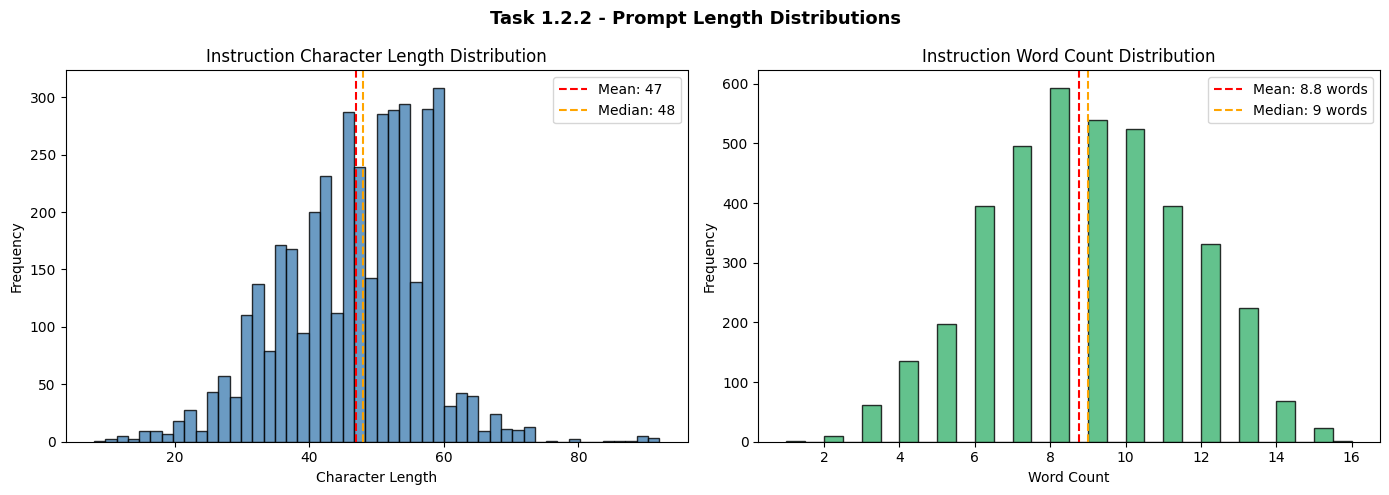


Token Distribution Estimate:
 (Exact subword token counts are computed in MB2 after Qwen tokenisation)
 Estimated avg tokens per instruction  : ~11
 Estimated max tokens per instruction  : ~24
 With system prompt (~30 tok) + JSON target (~20 tok):
   Total estimated avg sequence length : ~61 tokens
   Comfortably within MAX_LENGTH=256 set in MB2 - low truncation risk.


In [ ]:
#prompt length and token token distribution
import matplotlib.pyplot as plt

# Calculate character and word lengths on the sampled data
sampled_df['char_length'] = sampled_df['instruction'].str.len()
sampled_df['word_count'] = sampled_df['instruction'].str.split().str.len()

print("Instruction Character Length Statistics:")
print(sampled_df['char_length'].describe().round(2))
print("\nInstruction Word Count Statistics:")
print(sampled_df['word_count'].describe().round(2))

# Outlier check - top 5% longest instructions
p95_char = sampled_df['char_length'].quantile(0.95)
long_prompts = sampled_df[sampled_df['char_length'] > p95_char]
print(f"\nTop 5% longest instructions (>= {p95_char:.0f} chars): {len(long_prompts)} samples")
print("Longest instruction sample:", sampled_df.nlargest(1, 'char_length')['instruction'].values[0][:100])

# Plot both distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sampled_df['char_length'], bins=50, edgecolor='black', color='steelblue', alpha=0.8)
axes[0].axvline(sampled_df['char_length'].mean(), color='red', linestyle='--',
              label=f"Mean: {sampled_df['char_length'].mean():.0f}")
axes[0].axvline(sampled_df['char_length'].median(), color='orange', linestyle='--',
              label=f"Median: {sampled_df['char_length'].median():.0f}")
axes[0].set_title('Instruction Character Length Distribution')
axes[0].set_xlabel('Character Length')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(sampled_df['word_count'], bins=30, edgecolor='black', color='mediumseagreen', alpha=0.8)
axes[1].axvline(sampled_df['word_count'].mean(), color='red', linestyle='--',
              label=f"Mean: {sampled_df['word_count'].mean():.1f} words")
axes[1].axvline(sampled_df['word_count'].median(), color='orange', linestyle='--',
              label=f"Median: {sampled_df['word_count'].median():.0f} words")
axes[1].set_title('Instruction Word Count Distribution')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Task 1.2.2 - Prompt Length Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Token distribution estimate
print("\nToken Distribution Estimate:")
print(" (Exact subword token counts are computed in MB2 after Qwen tokenisation)")
avg_words = sampled_df['word_count'].mean()
est_avg_tokens = avg_words * 1.3  # Qwen tokeniser averages ~1.2-1.3 tokens/word on short noisy text
est_max_tokens = sampled_df['word_count'].max() * 1.5
print(f" Estimated avg tokens per instruction  : ~{est_avg_tokens:.0f}")
print(f" Estimated max tokens per instruction  : ~{est_max_tokens:.0f}")
print(f" With system prompt (~30 tok) + JSON target (~20 tok):")
print(f"   Total estimated avg sequence length : ~{est_avg_tokens + 50:.0f} tokens")
print(f"   Comfortably within MAX_LENGTH=256 set in MB2 - low truncation risk.")

#### **1.2.3 Validate Sample Quality [2 marks]**
**The Task:** Identify and remove records containing null values or duplicated customer instructions using normalised deduplication.

**Hints & Tips:**
* Use `.isnull().sum()` to check nulls.
* Simple `drop_duplicates` misses near-dupes like `"Where is my order?"` vs `"where is my order?"`.
* Normalise to lowercase + strip whitespace BEFORE deduplicating to catch these.
* The Bitext dataset typically has ~15 near-duplicates in a 4000-row sample.

**Learner Inference:** Cleaning now prevents "garbage-in, garbage-out". Duplicate prompts can cause leakage between train and test sets later.

In [ ]:
# Check for null values
null_counts = sampled_df.isnull().sum()
print("Null values before cleaning:")
print(null_counts)

# Remove rows with any null values (if any)
initial_rows = len(sampled_df)
sampled_df.dropna(inplace=True)
rows_after_null_drop = len(sampled_df)
print(f"\n{initial_rows - rows_after_null_drop} rows removed due to null values.")

# Perform normalized deduplication on 'instruction' column
# Create a normalized version of the instruction for deduplication
sampled_df['normalized_instruction'] = sampled_df['instruction'].str.lower().str.strip()

# Identify duplicates based on the normalized instruction
duplicates = sampled_df.duplicated(subset=['normalized_instruction'], keep='first')
num_duplicates = duplicates.sum()

# Remove duplicates
sampled_df = sampled_df[~duplicates].copy()

# Drop the temporary normalized_instruction column
sampled_df.drop(columns=['normalized_instruction'], inplace=True)

print(f"\n{num_duplicates} duplicate (or near-duplicate) instructions removed.")
print(f"Final dataset size after cleaning: {len(sampled_df)} rows")

# Display updated info and head
print("\nCleaned DataFrame Info:")
sampled_df.info()
print("\nFirst 5 rows of the cleaned dataset:")
print(sampled_df.head())

Null values before cleaning:
flags          0
instruction    0
category       0
intent         0
response       0
char_length    0
word_count     0
dtype: int64

0 rows removed due to null values.

98 duplicate (or near-duplicate) instructions removed.
Final dataset size after cleaning: 3902 rows

Cleaned DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 3902 entries, 9329 to 18057
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   flags        3902 non-null   object
 1   instruction  3902 non-null   object
 2   category     3902 non-null   object
 3   intent       3902 non-null   object
 4   response     3902 non-null   object
 5   char_length  3902 non-null   int64 
 6   word_count   3902 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 243.9+ KB

First 5 rows of the cleaned dataset:
       flags                                        instruction category  \
9329     BLZ                   I can'

### **Task 1.3: Perform Exploratory Data Analysis**

#### **1.3.1 Perform Univariate Analysis [2 marks]**
**The Task:** Plot the top 10 most frequent customer intents using a horizontal bar chart.

**Hints & Tips:**
* Use a Seaborn `countplot` with `order=df['intent'].value_counts().index[:10]`.
* Check if any single intent dominates >80% of data — signals severe class imbalance.
* `palette="viridis"` works well for accessibility.

**Learner Inference:** This visual reveals class imbalance. If one intent dominates, your fine-tuned router becomes biased toward guessing it.

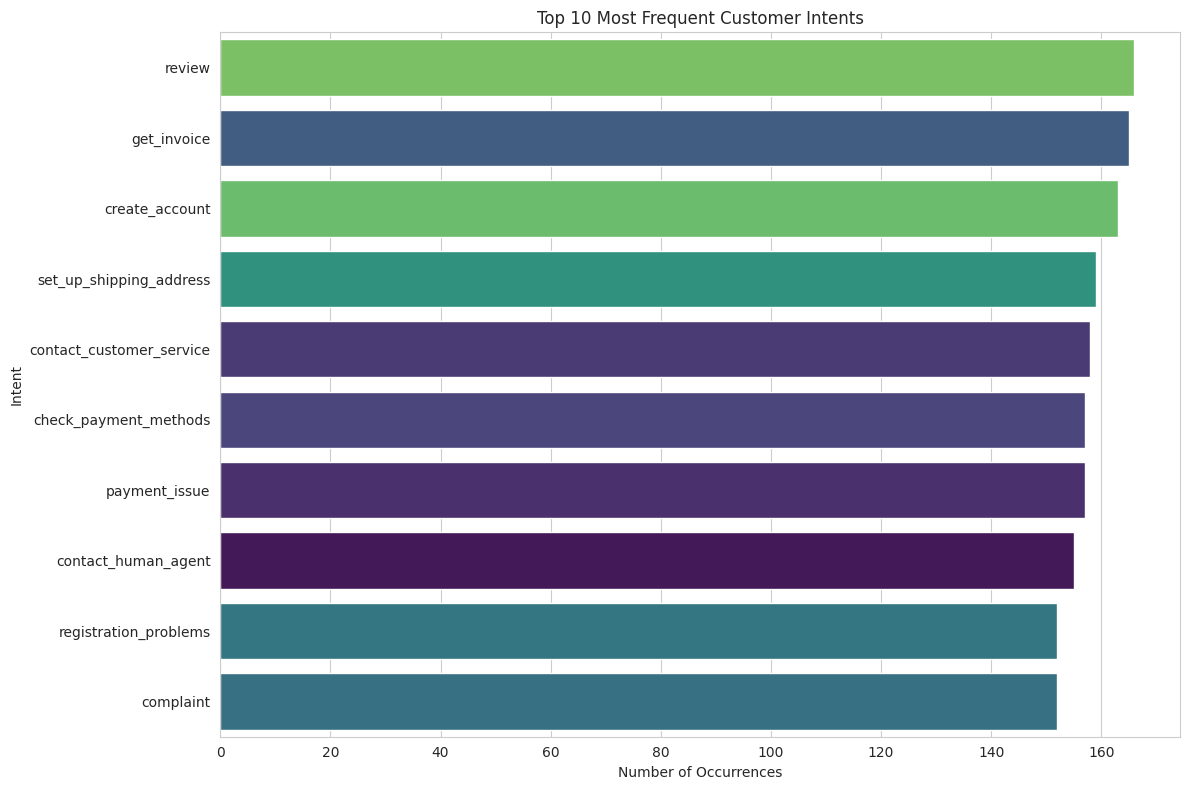

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Create the count plot for the top 10 intents
plt.figure(figsize=(12, 8))
sns.countplot(data=sampled_df,
    y='intent',
    order=sampled_df['intent'].value_counts().index[:10],
    palette='viridis',
    hue='intent',
    legend=False
)

plt.title('Top 10 Most Frequent Customer Intents')
plt.xlabel('Number of Occurrences')
plt.ylabel('Intent')
plt.tight_layout()
plt.show()

#### **1.3.2 Perform Bivariate Analysis [2 marks]**
**The Task:** Read the text from the uploaded Markdown SOP files and fit a `TfidfVectorizer` (with `stop_words='english'`) to transform them into vectors.

**Hints & Tips:**
* Read files into a list of strings first using `open(f, 'r').read()`.
* `TfidfVectorizer(stop_words="english")` removes common words, keeping meaningful terms.
* The resulting matrix shape should be `(num_docs, num_unique_terms)`.

**Learner Inference:** This transforms raw text into math, letting you prove whether your policies are distinct enough for an AI to tell apart.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the content of the markdown files
sop_contents = []
sop_basenames = []

for file_path in md_files:
    with open(file_path, 'r', encoding='utf-8') as f:
        sop_contents.append(f.read())
    sop_basenames.append(file_path.split('/')[-1])

print(f"Loaded {len(sop_contents)} SOP documents.")

# Initialize TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer(stop_words='english')

# Fit and transform the SOP document contents
sop_tfidf_matrix = tfidf_vectorizer.fit_transform(sop_contents)

print(f"TF-IDF matrix shape: {sop_tfidf_matrix.shape}")
print("First 5 feature names:")
print(tfidf_vectorizer.get_feature_names_out()[:5])

Loaded 13 SOP documents.
TF-IDF matrix shape: (13, 797)
First 5 feature names:
['00' '08' '10' '12' '18']


#### **1.3.3 Generate Visualisations [2 marks]**
**The Task:** Calculate cosine similarity between the TF-IDF vectors of the SOP documents and plot an annotated heatmap.

**Hints & Tips:**
* Use `cosine_similarity` from sklearn and `sns.heatmap` with `annot=True`.
* Diagonal should always be 1.0 (document vs itself).
* Off-diagonal >0.5 = high overlap (RAG may struggle); <0.3 = low overlap (good retrieval).

**Learner Inference:** High overlap (dark off-diagonal squares) means the RAG system struggles to fetch the right doc. Low overlap proves retrieval will be accurate.

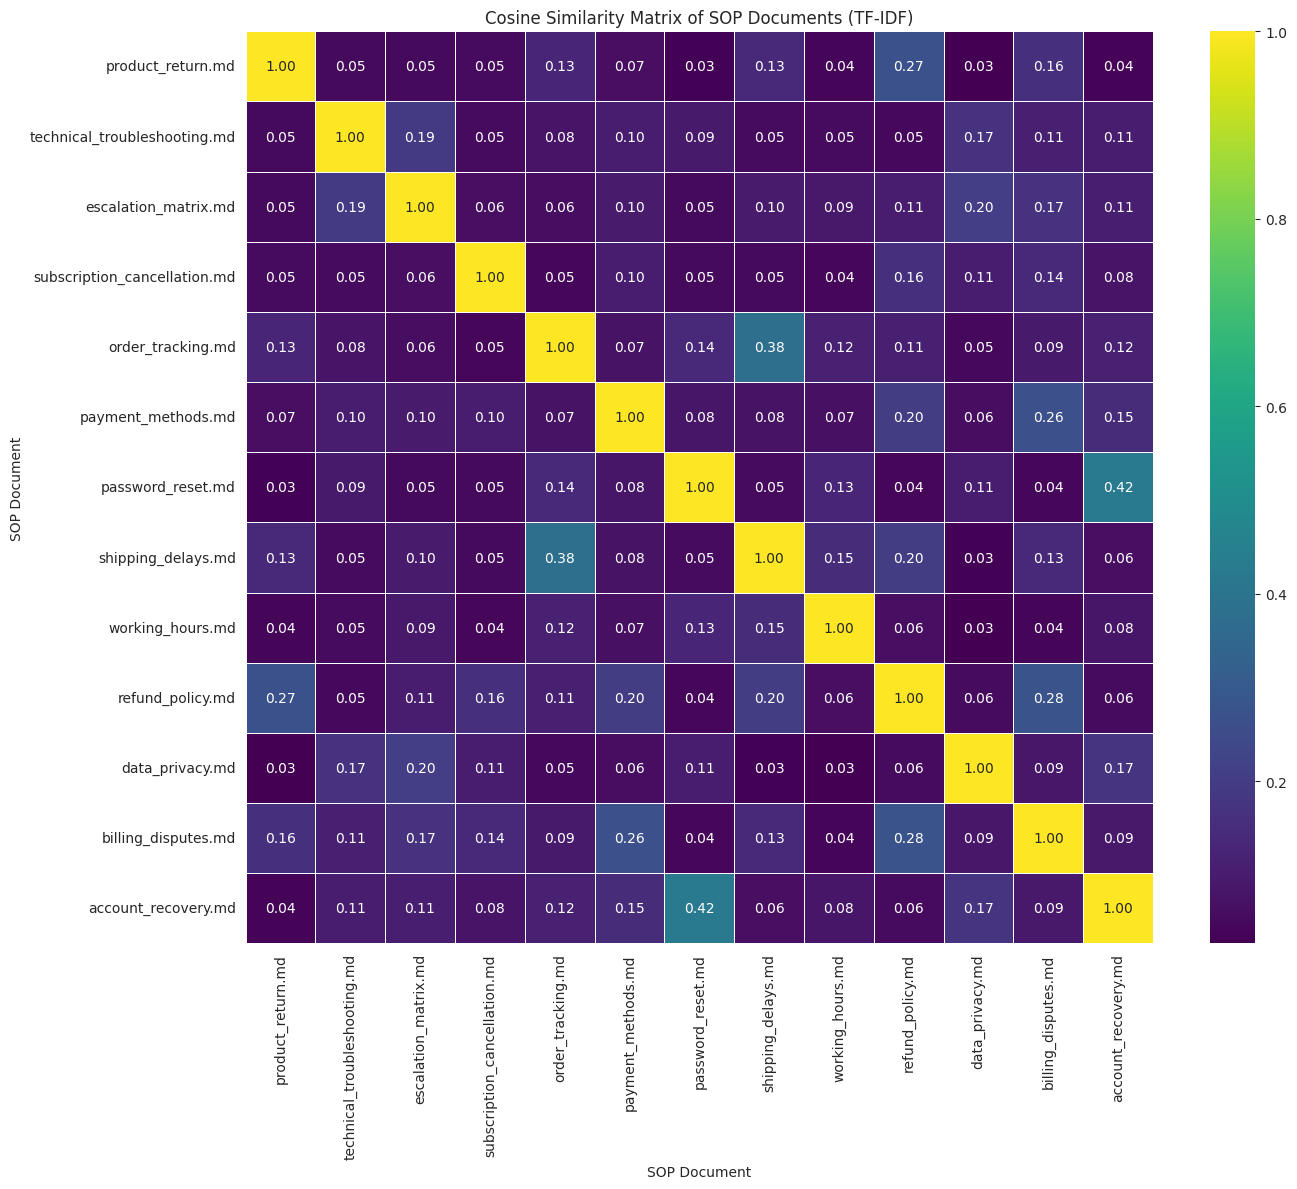

In [ ]:
import glob
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'sop_documents_path' is defined in a prior cell. If not, uncomment and define it:
# sop_documents_path = '/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sop_documents'

# Assuming 'md_files' is defined from a prior cell. If not, uncomment and define it:
# md_files = glob.glob(f'{sop_documents_path}/*.md')

# Load the content of the markdown files (re-running the logic from cell jPfzkmE2w6en)
sop_contents = []
sop_basenames = []
for file_path in md_files:
    with open(file_path, 'r', encoding='utf-8') as f:
        sop_contents.append(f.read())
    sop_basenames.append(file_path.split('/')[-1])

# Initialize TfidfVectorizer and fit_transform (re-running the logic from cell jPfzkmE2w6en)
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
sop_tfidf_matrix = tfidf_vectorizer.fit_transform(sop_contents)

# Calculate cosine similarity matrix
cosine_sim_matrix = cosine_similarity(sop_tfidf_matrix)

# Create a DataFrame for better visualization with seaborn
cosine_sim_df = pd.DataFrame(cosine_sim_matrix, index=sop_basenames, columns=sop_basenames)

# Plot the heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(cosine_sim_df, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Cosine Similarity Matrix of SOP Documents (TF-IDF)')
plt.xlabel('SOP Document')
plt.ylabel('SOP Document')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### **Interpretation of the Cosine Similarity Heatmap (Summary)**

The heatmap reveals that SOP documents are highly similar to themselves (diagonal values ~1.0) but generally distinct from each other (low off-diagonal values). This low inter-document similarity is ideal for a RAG system, as it ensures effective retrieval of specific policy documents without significant overlap or confusion between them.

---
## Save Artifacts for Notebook 2

**IMPORTANT:** This cell saves the cleaned DataFrame. Notebook 2 depends on this file.

In [ ]:
output_path = '/content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sampled_data.csv'
sampled_df.to_csv(output_path, index=False)
print(f"Saved 'sampled_data.csv' to Google Drive at {output_path}")

Saved 'sampled_data.csv' to Google Drive at /content/drive/MyDrive/upgrad AI/Assignment/RAG_Hybrid/Dataset/Dataset/sampled_data.csv


---
## END-OF-NOTEBOOK CHECKLIST

> **IMPORTANT: Verify all items before proceeding to Notebook 2.**

- [x] Bitext dataset loaded and `.info()` printed
- [x] Dataset sampled to 4000 rows (or chosen size 1000–5000)
- [x] Nulls inspected, near-duplicates removed via normalised dedup
- [x] Top 10 intent bar chart rendered
- [x] TF-IDF vectorisation completed on SOP documents
- [x] Cosine similarity heatmap rendered
- [x] **`sampled_data.csv` saved to disk** ← _CRITICAL for Notebook 2_
- [x] `corporate_policies/` folder still accessible ← _Needed in Notebooks 2 and 4_

**If any item is unchecked, fix it before moving on.**